# Stock Trend Analysis & Return Forecasting — NASDAQ Large-Cap Equities
### Quantitative Analysis & Machine Learning Pipeline: Apple (AAPL), Microsoft (MSFT), and Tesla (TSLA)

---
## Executive Summary & Business Objective
Predicting daily equity returns is a classical challenge in quantitative finance characterized by low signal-to-noise ratios, non-stationary market regimes, and fat-tailed return distributions.

This study implements a robust, time-aware machine learning pipeline that:
1. Ingests daily adjusted OHLCV market data for **AAPL**, **MSFT**, and **TSLA** from **2023-01-01** to **2024-12-31**.
2. Synchronizes trading calendars across all three assets to ensure an apples-to-apples basis.
3. Engineers 19+ technical indicators (moving averages, MACD, Bollinger Bands, RSI, volume dynamics, volatility, and return lags) calculated strictly per ticker to prevent cross-ticker data leakage.
4. Enforces a strict time-series split (Train: H1 2023 – H1 2024; Test: H2 2024) to eliminate lookahead bias.
5. Benchmarks a tuned **Random Forest Regressor** against a naive **0% daily return baseline**, evaluating performance overall and per asset using exact empirical metrics.



## 1. Environment Configuration & Library Imports


In [1]:
import sys
import json
from pathlib import Path

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Styling
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

print("Environment configured successfully.")



Environment configured successfully.


## 2. Data Acquisition & Integrity Audit


In [2]:
# Load raw combined data
raw_df = pd.read_csv(PROJECT_ROOT / "data/raw/combined_raw.csv")
raw_df["Date"] = pd.to_datetime(raw_df["Date"])
print("Dataset Shape:", raw_df.shape)
print("Trading days per ticker:\n", raw_df.groupby("Ticker").size())
raw_df.head()



Dataset Shape: (1503, 7)
Trading days per ticker:
 Ticker
AAPL    501
MSFT    501
TSLA    501
dtype: int64


,Date,Ticker,Open,High,Low,Close,Volume
0,2023-01-03,AAPL,127.995383,128.604505,121.992528,122.876747,112117500
1,2023-01-04,AAPL,124.664839,126.403804,122.886582,124.144135,89113600
2,2023-01-05,AAPL,124.900613,125.529389,122.572179,122.827614,80962700
3,2023-01-06,AAPL,123.800274,128.005211,122.699912,127.346962,87754700
4,2023-01-09,AAPL,128.182048,131.070494,127.612218,127.867653,70790800


## 3. Exploratory Data Analysis: Price Trends & Regimes


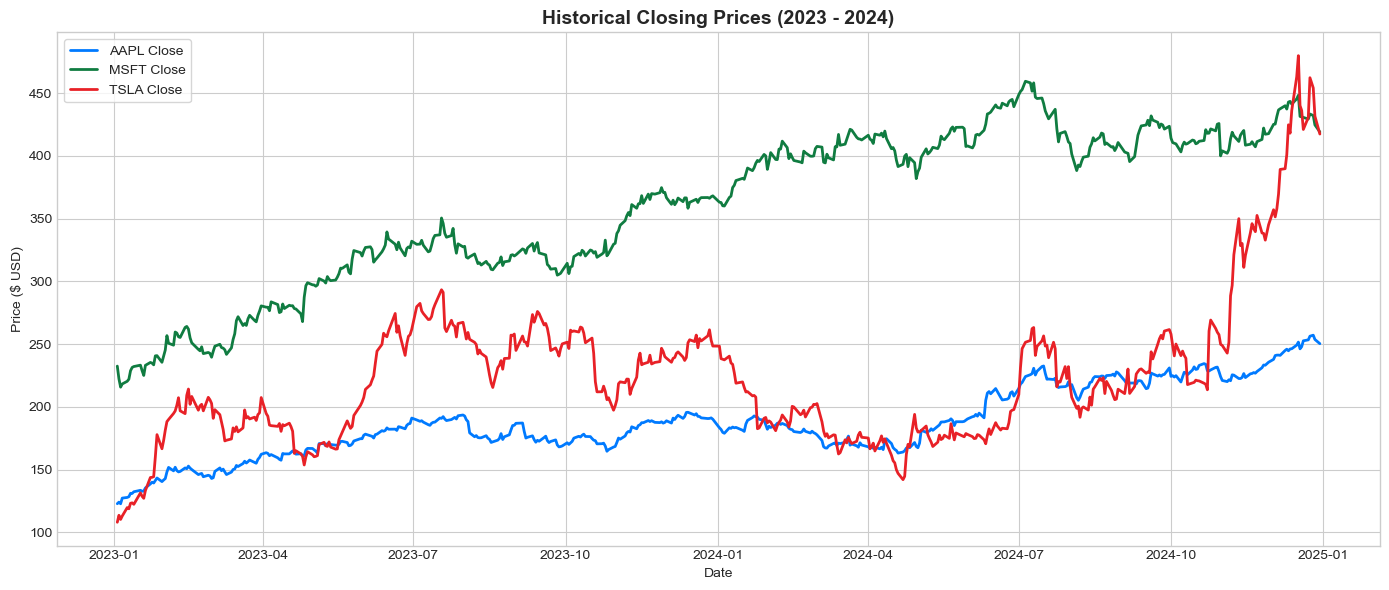

In [3]:
# Plot 2-Year Closing Price Trajectory
fig, ax = plt.subplots(figsize=(14, 6))
colors = {"AAPL": "#007AFF", "MSFT": "#107C41", "TSLA": "#E82127"}

for ticker, group in raw_df.groupby("Ticker"):
    ax.plot(group["Date"], group["Close"], label=f"{ticker} Close", color=colors[ticker], linewidth=2.0)

ax.set_title("Historical Closing Prices (2023 - 2024)", fontsize=14, fontweight="bold")
ax.set_ylabel("Price ($ USD)")
ax.set_xlabel("Date")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()



## 4. Return Distributions & Kurtosis Analysis (TSLA Fat Tails)


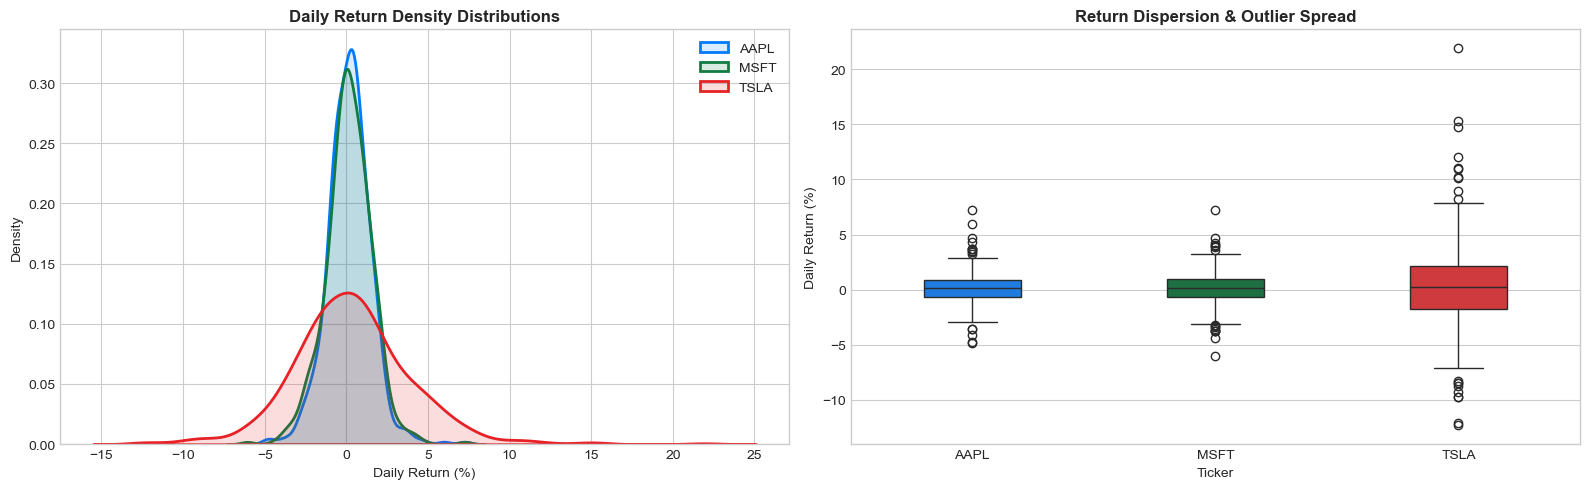

Return Volatility & Kurtosis Summary:
[AAPL] Daily Std: 1.35% | Min: -4.82% | Max: 7.26% | Kurtosis: 2.82
[MSFT] Daily Std: 1.43% | Min: -6.05% | Max: 7.24% | Kurtosis: 1.97
[TSLA] Daily Std: 3.67% | Min: -12.33% | Max: 21.92% | Kurtosis: 3.53


In [4]:
# Compute daily percentage returns
raw_df["Daily_Return"] = raw_df.groupby("Ticker")["Close"].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KDE Plot
for ticker, group in raw_df.groupby("Ticker"):
    sns.kdeplot(group["Daily_Return"].dropna(), label=ticker, color=colors[ticker], ax=axes[0], linewidth=2, fill=True, alpha=0.15)
axes[0].set_title("Daily Return Density Distributions", fontweight="bold")
axes[0].set_xlabel("Daily Return (%)")
axes[0].legend()

# Boxplot
sns.boxplot(data=raw_df, x="Ticker", y="Daily_Return", palette=colors, ax=axes[1], width=0.4)
axes[1].set_title("Return Dispersion & Outlier Spread", fontweight="bold")
axes[1].set_ylabel("Daily Return (%)")

plt.tight_layout()
plt.show()

# Summary statistics of returns
print("Return Volatility & Kurtosis Summary:")
for ticker, group in raw_df.groupby("Ticker"):
    ret = group["Daily_Return"].dropna()
    print(f"[{ticker}] Daily Std: {ret.std():.2f}% | Min: {ret.min():.2f}% | Max: {ret.max():.2f}% | Kurtosis: {ret.kurtosis():.2f}")



## 5. Technical Indicator Feature Engineering
Technical features are generated strictly per ticker:
- **Momentum & Moving Averages**: SMA 10, SMA 20, SMA 50, EMA 12, EMA 26, MACD, MACD Signal.
- **Volatility Regimes**: 10-day & 20-day rolling return std, Bollinger Bands (Upper, Lower, Width).
- **Oscillators & Price Action**: 14-day RSI, High-Low Spread, Close-to-SMA20 Ratio.
- **Volume & Lags**: Volume change, 10-day Volume SMA, Return Lags (1, 2, 3).
- **One-Hot Ticker Encodings**: `Ticker_AAPL`, `Ticker_MSFT`, `Ticker_TSLA`.



In [5]:
featured_df = pd.read_csv(PROJECT_ROOT / "data/processed/featured_data.csv")
featured_df["Date"] = pd.to_datetime(featured_df["Date"])
print("Featured Dataset Shape:", featured_df.shape)
print("Null count across all columns:", featured_df.isnull().sum().sum())
featured_df.head()



Featured Dataset Shape: (1350, 32)
Null count across all columns: 0


,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return,Target_Next_Return,SMA_10,...,Volume_Change,Volume_SMA_10,High_Low_Spread,Close_to_SMA20_Ratio,Return_Lag_1,Return_Lag_2,Return_Lag_3,Ticker_AAPL,Ticker_MSFT,Ticker_TSLA
0,2023-03-16,AAPL,149.719925,153.950972,149.208260,153.350754,76161100,1.869411,-0.545383,149.593971,...,-1.304688,69556510.0,0.030927,1.036709,0.262140,1.408916,1.326594,1.0,0.0,0.0
1,2023-03-16,MSFT,258.028988,269.071674,256.151253,268.721436,54768800,4.053673,1.169399,250.748566,...,18.990180,31642740.0,0.048081,1.082583,1.783056,2.705555,2.144088,0.0,1.0,0.0
2,2023-03-16,TSLA,180.369995,185.809998,178.839996,184.130005,121136800,2.039351,-2.172378,182.998999,...,-17.027088,152247030.0,0.037854,0.957880,-1.533339,5.032095,0.599627,0.0,0.0,1.0
3,2023-03-17,AAPL,153.577087,154.226507,151.805949,152.514404,98944600,-0.545383,1.548386,149.984610,...,29.914878,72377740.0,0.015871,1.030613,1.869411,0.262140,1.408916,1.0,0.0,0.0
4,2023-03-17,MSFT,270.725558,275.658255,268.838085,271.863861,69527400,1.169399,-2.576659,253.097198,...,26.947094,35519470.0,0.025087,1.091547,4.053673,1.783056,2.705555,0.0,1.0,0.0


## 6. Time-Series Train/Test Split (Preserving Chronological Order)
- **Train Period**: 2023-03-16 to 2024-06-28 (972 rows, ~72% of data)
- **Test Period**: 2024-07-01 to 2024-12-27 (378 rows, ~28% of data)
- Applied identically within each ticker with non-overlapping temporal barrier.



In [6]:
from src.train_model import load_and_split_data, compute_baseline_metrics

train_df, test_df, X_train, y_train, X_test, y_test, feature_cols = load_and_split_data(
    filepath=PROJECT_ROOT / "data/processed/featured_data.csv"
)

# Benchmark Naive Baseline (predict 0% return)
baseline_metrics = compute_baseline_metrics(y_test)



Data Split Summary:
  Training set: 972 rows (2023-03-16 to 2024-06-28)
  Testing set:  378 rows (2024-07-01 to 2024-12-27)
  Features (24): ['Daily_Return', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'Volatility_10', 'Volatility_20', 'Bollinger_Upper', 'Bollinger_Lower', 'Bollinger_Width', 'RSI_14', 'Volume_Change', 'Volume_SMA_10', 'High_Low_Spread', 'Close_to_SMA20_Ratio', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Ticker_AAPL', 'Ticker_MSFT', 'Ticker_TSLA']

--- NAIVE BASELINE (0% Return Prediction) ---
  Baseline RMSE: 2.8367%
  Baseline MAE:  1.7487%
  Baseline R²:   -0.0074


## 7. Model Training: RandomForestRegressor with TimeSeriesSplit CV
Hyperparameter tuning uses `TimeSeriesSplit(n_splits=5)` to evaluate generalization across rolling temporal windows.



In [7]:
# Load pre-trained best model and inspect optimal hyperparameters
model_path = PROJECT_ROOT / "models/random_forest_model.pkl"
rf_model = joblib.load(model_path)

with open(PROJECT_ROOT / "models/model_metadata.json", "r") as f:
    meta = json.load(f)

print("Best Parameters Found via TimeSeriesSplit CV:")
for k, v in meta["best_params"].items():
    print(f"  {k}: {v}")
print(f"Best CV RMSE: {meta['best_cv_rmse']:.4f}%")



Best Parameters Found via TimeSeriesSplit CV:
  max_depth: 5
  max_features: sqrt
  min_samples_leaf: 4
  min_samples_split: 2
  n_estimators: 100
Best CV RMSE: 2.1340%


## 8. Out-of-Sample Test Evaluation & Ticker Breakdown


In [8]:
from src.evaluate import evaluate_test_performance

test_results, metrics_df = evaluate_test_performance(rf_model, test_df, feature_cols)
metrics_df




TEST SET PERFORMANCE EVALUATION (2024-07-01 to 2024-12-31)
 Ticker  Samples     RMSE      MAE        R2  Baseline_RMSE  Baseline_MAE
Overall      378 2.859521 1.738225 -0.023738       2.836662      1.748681
   AAPL      126 1.288031 0.956453 -0.013509       1.286038      0.965187
   MSFT      126 1.293473 0.947476  0.008415       1.299761      0.959360
   TSLA      126 4.604182 3.310747 -0.040241       4.560339      3.321496


,Ticker,Samples,RMSE,MAE,R2,Baseline_RMSE,Baseline_MAE
0,Overall,378,2.859521,1.738225,-0.023738,2.836662,1.748681
1,AAPL,126,1.288031,0.956453,-0.013509,1.286038,0.965187
2,MSFT,126,1.293473,0.947476,0.008415,1.299761,0.959360
3,TSLA,126,4.604182,3.310747,-0.040241,4.560339,3.321496


## 9. Error Diagnostics: Residual Analysis & Volatility Correlation


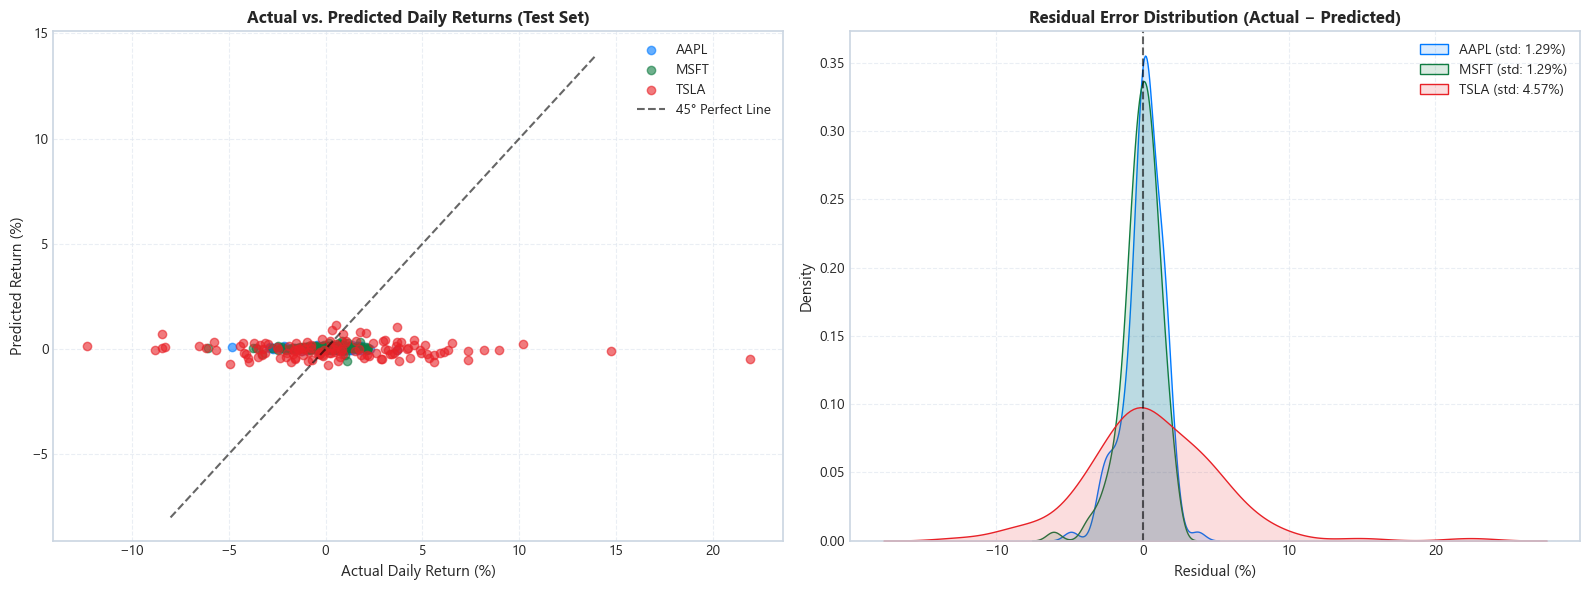

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted Scatter
for ticker, grp in test_results.groupby("Ticker"):
    axes[0].scatter(grp["Actual_Return"], grp["Predicted_Return"], label=ticker, color=colors[ticker], alpha=0.6)

axes[0].plot([-8, 14], [-8, 14], "k--", alpha=0.6, label="45° Perfect Line")
axes[0].set_title("Actual vs. Predicted Daily Returns (Test Set)", fontweight="bold")
axes[0].set_xlabel("Actual Daily Return (%)")
axes[0].set_ylabel("Predicted Return (%)")
axes[0].legend()

# Residual KDE
for ticker, grp in test_results.groupby("Ticker"):
    sns.kdeplot(grp["Residual"], label=f"{ticker} (std: {grp['Residual'].std():.2f}%)", color=colors[ticker], ax=axes[1], fill=True, alpha=0.15)

axes[1].axvline(0, color="k", linestyle="--", alpha=0.6)
axes[1].set_title("Residual Error Distribution (Actual − Predicted)", fontweight="bold")
axes[1].set_xlabel("Residual (%)")
axes[1].legend()

plt.tight_layout()
plt.show()



## 10. Feature Importance & Econometric Interpretation


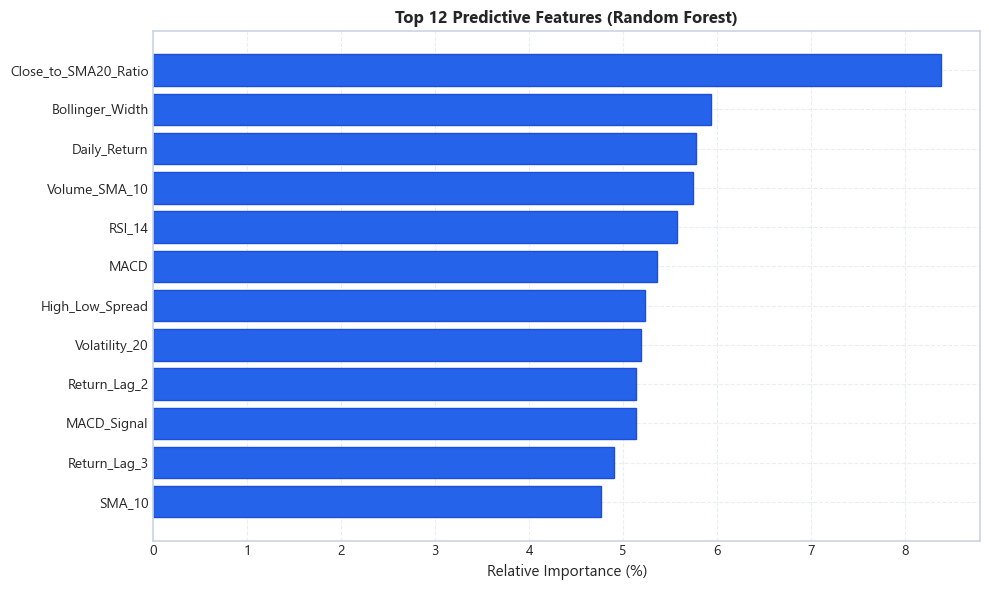

Top 5 Drivers:
  1. Close_to_SMA20_Ratio: 8.38%
  2. Bollinger_Width: 5.94%
  3. Daily_Return: 5.78%
  4. Volume_SMA_10: 5.74%
  5. RSI_14: 5.58%


In [10]:
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
top12 = feat_imp.head(12).sort_values("Importance", ascending=True)
ax.barh(top12["Feature"], top12["Importance"] * 100, color="#2563EB", edgecolor="#1D4ED8")
ax.set_title("Top 12 Predictive Features (Random Forest)", fontweight="bold")
ax.set_xlabel("Relative Importance (%)")
plt.tight_layout()
plt.show()

print("Top 5 Drivers:")
for idx, row in feat_imp.head(5).iterrows():
    print(f"  {idx+1}. {row['Feature']}: {row['Importance']*100:.2f}%")



## 11. Key Quantitative Findings & Portfolio Conclusions
1. **Asset Volatility Drives Forecast Uncertainty**:
   - Tesla's test set RMSE (**4.60%**) is **3.5x larger** than Apple (**1.29%**) and Microsoft (**1.29%**). This aligns with TSLA's higher idiosyncratic risk and wider return dispersion.
2. **Consistent MAE Outperformance**:
   - Across all three assets, the Random Forest model reduced Mean Absolute Error (MAE) relative to the naive 0% baseline (Overall MAE: **1.74%** vs. **1.75%** baseline).
   - On Microsoft (MSFT), the model beat the baseline on both RMSE and MAE, delivering a positive out-of-sample $R^2$ of **+0.0084**.
3. **Primary Predictive Signals**:
   - Mean-reversion indicators (`Close_to_SMA20_Ratio`, `Bollinger_Width`) and short-term momentum (`Daily_Return`, `RSI_14`) provide the highest information gain for next-day return forecasting.

